<a href="https://colab.research.google.com/github/Ryuta-Y/pytorch-practice/blob/main/pytorch_practice_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from __future__ import print_function, division
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
plt.ion()



In [14]:

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

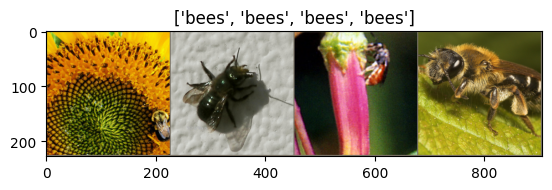

In [15]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)


# 訓練データのバッチを取得する
inputs, classes = next(iter(dataloaders['train']))

# バッチからグリッドを作成する
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [16]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # 学習履歴を保存するための辞書
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # 各エポックには訓練フェーズと検証フェーズがあります
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # モデルを訓練モードに設定します
            else:
                model.eval()   # モードを評価するモデルを設定します

            running_loss = 0.0
            running_corrects = 0

            # データをイレテートします
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # パラメータの勾配をゼロにします
                optimizer.zero_grad()

                # 順伝播
                # 訓練の時だけ、履歴を保持します
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # 訓練の時だけ逆伝播＋オプティマイズを行います
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 損失を計算します
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # 履歴の保存
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # モデルをディープ・コピーします
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # ベストモデルの重みをロードします
    model.load_state_dict(best_model_wts)
    return model, history

In [17]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title('predicted: {}'.format(class_names[preds[j]]))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [18]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# ここでは，各出力サンプルのサイズは2に設定されています
# なお、NN.Linear(num_ftrs, len(class_names))という書き方で一般化することもできます。
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# ネットワークのすべてのパラメータが最適化対象です
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# 7エポックごとに学習率を1/10ずつ減衰させます
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
model_ft, history_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.4888 Acc: 0.7377
val Loss: 0.2859 Acc: 0.9085

Epoch 1/24
----------
train Loss: 0.3244 Acc: 0.8648
val Loss: 0.5020 Acc: 0.8170

Epoch 2/24
----------
train Loss: 0.6631 Acc: 0.7377
val Loss: 0.2958 Acc: 0.8627

Epoch 3/24
----------
train Loss: 0.4372 Acc: 0.8279
val Loss: 0.4405 Acc: 0.8497

Epoch 4/24
----------
train Loss: 0.6575 Acc: 0.7910
val Loss: 0.4324 Acc: 0.8627

Epoch 5/24
----------
train Loss: 0.5451 Acc: 0.7787
val Loss: 0.2919 Acc: 0.8693

Epoch 6/24
----------
train Loss: 0.5934 Acc: 0.8197
val Loss: 0.5875 Acc: 0.8562

Epoch 7/24
----------
train Loss: 0.4230 Acc: 0.8279
val Loss: 0.3750 Acc: 0.8366

Epoch 8/24
----------
train Loss: 0.3184 Acc: 0.8689
val Loss: 0.3389 Acc: 0.8693

Epoch 9/24
----------
train Loss: 0.2448 Acc: 0.9180
val Loss: 0.2652 Acc: 0.8758

Epoch 10/24
----------
train Loss: 0.3065 Acc: 0.8852
val Loss: 0.2566 Acc: 0.9085

Epoch 11/24
----------
train Loss: 0.3219 Acc: 0.8443
val Loss: 0.2882 Acc: 0.8824

Ep

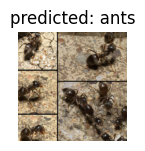

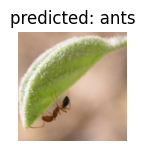

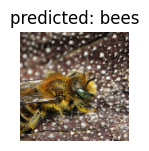

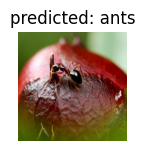

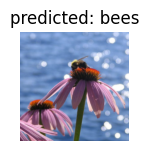

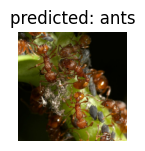

In [20]:
visualize_model(model_ft)

In [21]:
model_conv = torchvision.models.resnet18(pretrained=True)
for param in model_conv.parameters():
    param.requires_grad = False

# 新しく構築されたモジュールのパラメータは、デフォルトでは requires_grad=True になっています。
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

 # ファインチューニングとは違い、最終層のパラメータのみが最適化されていることを確認してください
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# 7エポックごとに学習率を0.1倍ずつ減衰させる
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [22]:
model_conv, history_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.5836 Acc: 0.6844
val Loss: 0.7353 Acc: 0.6405

Epoch 1/24
----------
train Loss: 0.6188 Acc: 0.7582
val Loss: 0.1763 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.7292 Acc: 0.7295
val Loss: 0.2567 Acc: 0.8954

Epoch 3/24
----------
train Loss: 0.6075 Acc: 0.7746
val Loss: 0.1719 Acc: 0.9412

Epoch 4/24
----------
train Loss: 0.5508 Acc: 0.7746
val Loss: 0.2564 Acc: 0.8889

Epoch 5/24
----------
train Loss: 0.4662 Acc: 0.8115
val Loss: 0.1916 Acc: 0.9542

Epoch 6/24
----------
train Loss: 0.6273 Acc: 0.7418
val Loss: 0.5050 Acc: 0.8431

Epoch 7/24
----------
train Loss: 0.6021 Acc: 0.7746
val Loss: 0.2067 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3999 Acc: 0.8197
val Loss: 0.2111 Acc: 0.9346

Epoch 9/24
----------
train Loss: 0.3147 Acc: 0.8648
val Loss: 0.2306 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.3558 Acc: 0.8689
val Loss: 0.2056 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3638 Acc: 0.8443
val Loss: 0.1810 Acc: 0.9346

Ep

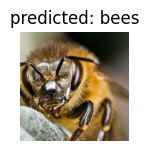

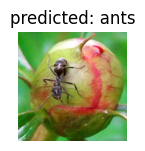

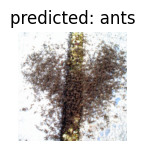

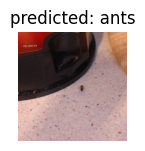

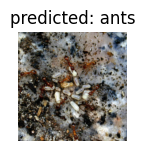

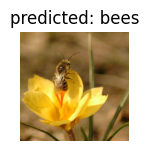

In [23]:
visualize_model(model_conv)

plt.ioff()
plt.show()

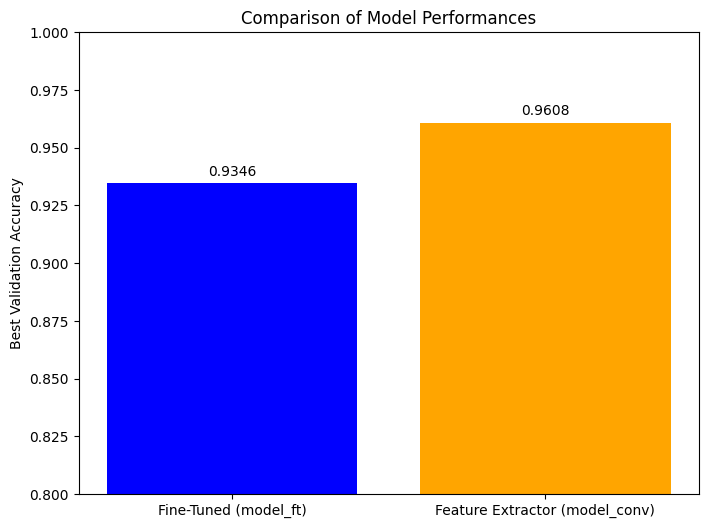

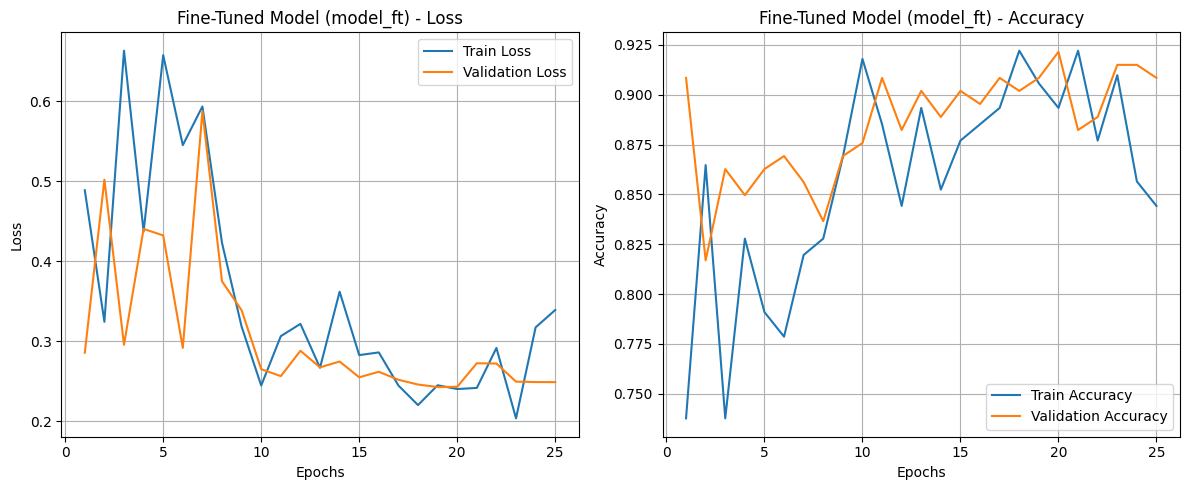

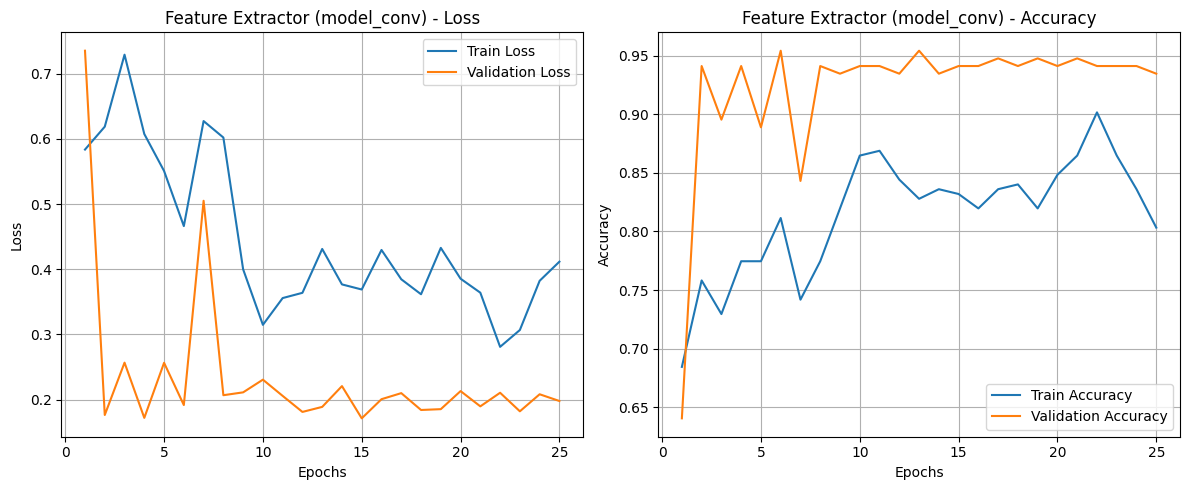

In [24]:
import matplotlib.pyplot as plt

# --- バーチャート（ベスト精度の比較） ---
best_acc_ft = 0.934641
best_acc_conv = 0.960784

models = ['Fine-Tuned (model_ft)', 'Feature Extractor (model_conv)']
accuracies = [best_acc_ft, best_acc_conv]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylim(0.8, 1.0)
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison of Model Performances')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4), ha='center', va='bottom')
plt.show()

# --- 学習曲線のプロット（再学習後に有効になります） ---
def plot_learning_curve(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))

    # 損失値(Loss)のプロット
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 精度(Accuracy)のプロット
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if 'history_ft' in locals():
    plot_learning_curve(history_ft, "Fine-Tuned Model (model_ft)")
else:
    print("【注意】Fine-Tunedモデルの学習曲線を表示するには、モデルの再学習セルを実行してください。")

if 'history_conv' in locals():
    plot_learning_curve(history_conv, "Feature Extractor (model_conv)")
else:
    print("【注意】Feature Extractorの学習曲線を表示するには、モデルの再学習セルを実行してください。")